In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [10]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


# Load HGA

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'LexicalNoDelay',
        'LexicalDelay',
        # 'PictureNaming',
        # 'SentenceRep',
        # 'PhonemeSequence',
        # 'TIMIT'
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'
HGAs.head()

100%|██████████| 497/497 [00:11<00:00, 43.42it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [186]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 288960
PIC electrode count: 271360


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


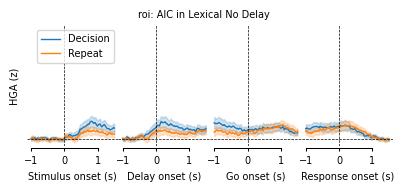

In [187]:
rois = ['AIC']
colors = [red, blue]

subset = HGAs[
    (HGAs.task.isin(['LexicalDelay']))
    & (HGAs.roi.isin(rois))
    & (HGAs.subject != 'D0121')
    # & (HGAs.hemi == 'L')
    & (HGAs.modality == 'sound')
]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

for (ax, phase) in zip(fig.axes, ['stimulus', 'delay', 'go', 'response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    
    line = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='description',
        ax=ax,
        legend=legend,
        lw=1
    )
    
    ax.set_ylim(-0.1, 1.2)


for ax in fig.axes:
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.5)
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Delay onset (s)', fontsize=7)   
ax3.set_xlabel('Go onset (s)', fontsize=7)   
ax4.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
ax4.set_ylabel('', fontsize=7)

plt.suptitle('roi: ' + rois[0] + ' in Lexical No Delay', fontsize=7)
# plt.savefig('../img/fig1/fig1_AIPI_temporal_PictureNaming.svg', dpi=300, bbox_inches='tight')
plt.show()

# Decision V.S  Repeat

In [189]:
# ── Load Decision vs Repeat univariate contrast results (BIDSPath style) ──
ref = 'bipolar'
contrast_paths = []
for t in ['LexicalNoDelay']:
    contrast_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='univariate',
            description='DecisionVsRepeat',
            suffix='highgamma',
            check=False,
        ).match()
    )

print(f"Found {len(contrast_paths)} contrast files")

contrast_dfs = []
for path in tqdm(contrast_paths):
    df = pd.read_csv(path)
    df['subject'] = path.subject
    df['task'] = path.task
    contrast_dfs.append(df)

dec_vs_rep = pd.concat(contrast_dfs, ignore_index=True)

# Merge ROI info from HGAs (channel + subject is unique key)
# Get unique channel metadata from HGAs
channel_meta = HGAs[['channel', 'roi', 'hemi', 'label', 'x', 'y', 'z']].drop_duplicates(subset='channel')
dec_vs_rep = dec_vs_rep.merge(channel_meta, on='channel', how='left')

# Exclude bad channels
dec_vs_rep = dec_vs_rep[~dec_vs_rep.channel.isin(exclude_chn)]

print(f"Total: {len(dec_vs_rep)} rows, {dec_vs_rep.subject.nunique()} subjects")
print(f"ROIs: {sorted(dec_vs_rep.roi.dropna().unique())}")


# take only the channel in HGAs
pick_chn = HGAs.channel.unique()
# dec_vs_rep = dec_vs_rep[dec_vs_rep.channel.isin(pick_chn)]
dec_vs_rep.head()

Found 25 contrast files


100%|██████████| 25/25 [00:00<00:00, 61.06it/s]


Total: 582080 rows, 25 subjects
ROIs: ['ACC', 'AG', 'AIC', 'Amyg', 'CC_Anterior', 'CGs', 'Calcarine', 'Cb', 'Central', 'CollatAnt', 'FuG', 'FuGs', 'GRect', 'HG', 'Hipp', 'IFG', 'IFGs', 'IPL', 'ITG', 'InfLatV', 'LinG', 'LinGs', 'MFG', 'MFGs', 'MTG', 'OFC', 'OFCs', 'OPC', 'OccS', 'PCC', 'PCun', 'PCuns', 'PIC', 'Paracentral', 'PhG', 'Put', 'SFG', 'SFGs', 'SMC', 'SMG', 'SPL', 'STG', 'STS', 'Sylvian', 'TP', 'Thal', 'VDC', 'dACC', 'iOccGs', 'mOccG']


,channel,time,mask,p,mean_a,mean_b,mean_diff,significant,direction,phase,subject,task,roi,hemi,label,x,y,z
0,D0024_LMST3-4,-1.000000,0,0.722256,0.114947,0.153243,-0.038296,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326
1,D0024_LMST3-4,-0.992188,0,0.655069,0.086653,0.151536,-0.064883,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326
2,D0024_LMST3-4,-0.984375,0,0.542292,0.053228,0.150837,-0.097609,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326
3,D0024_LMST3-4,-0.976562,0,0.493901,0.034315,0.140174,-0.105859,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326
4,D0024_LMST3-4,-0.968750,0,0.560688,0.033460,0.106091,-0.072632,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326


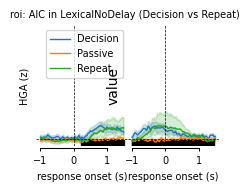

In [ ]:
rois = ['AIC']
task_name = 'LexicalNoDelay'

# HGA traces (same as your existing plot)
subset = HGAs[
    (HGAs.task == task_name)
    & (HGAs.roi.isin(rois))
    & (HGAs.subject != 'D0121')
    & (HGAs.modality == 'sound')
]

# Significance mask from univariate contrast
mask_df = dec_vs_rep[
    (dec_vs_rep.task == task_name)
    & (dec_vs_rep.roi.isin(rois))
]

phases = ['stimulus', 'response']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*len(phases)*cm, 4*cm),
                         gridspec_kw={'width_ratios': [2.5]*len(phases)})
plt.subplots_adjust(wspace=0)

for ax, phase in zip(axes, phases):
    legend = (ax == axes[0])
    
    # 1. Draw HGA traces split by Decision / Repeat
    sns.lineplot(
        data=subset[subset.phase == phase],
        x='time', y='value',
        hue='description',
        ax=ax, legend=legend, lw=1
    )
    
    # 2. Overlay significance bar from contrast
    phase_mask = mask_df[mask_df.phase == phase]
    if len(phase_mask) > 0:
        # aggregate: at each time point, is ANY channel in this ROI significant?
        sig_times = phase_mask.groupby('time')['mask'].any()
        sig_t = sig_times[sig_times].index.values
        if len(sig_t) > 0:
            for t in sig_t:
                ax.axvspan(t - 0.004, t + 0.004, ymin=0, ymax=0.05,
                           color='black', alpha=0.8)

for ax in axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.1, 1.5)

    ax.set_xlabel(f'{phase} onset (s)', fontsize=7)

axes[0].set_ylabel('HGA (z)', fontsize=7)

plt.suptitle(f'roi: {rois[0]} in {task_name} (Decision vs Repeat)', fontsize=7)
plt.show()

In [190]:
# ==========================================
# NEW VERSION: Use mean_diff directly from CSV
# ==========================================
task_name = 'LexicalNoDelay'
phase = 'response'
sig_points = dec_vs_rep[
    (dec_vs_rep.task == task_name) & 
    (dec_vs_rep.significant == True) &
    (dec_vs_rep['mask'] == True) &
    (dec_vs_rep.phase == phase) &
    (dec_vs_rep.time>-0.5) &   
    (dec_vs_rep.time<1)
]

# 2. 对每个 channel 和 phase，计算显著时间窗口内的平均 delta (mean_diff)
# 因为 mean_diff 已经是 Decision - Repeat 了，直接求平均即可
# 合并 ROI：把沟(sulcus, 带s后缀)合并到对应的回(gyrus)
roi_merge = {
    'MFGs': 'MFG',
    'OFCs': 'OFC',
    'SFGs': 'SFG',
    'IFGs': 'IFG',
    'CGs': 'CG',
    'PCuns': 'PCun',
    'LinGs': 'LinG',
    'iOccGs': 'iOccG',
}
sig_points['roi'] = sig_points['roi'].replace(roi_merge)

significant_delta = sig_points.groupby(
    ['channel', 'phase', 'roi', 'hemi', 'label', 'x', 'y', 'z']
)['mean_diff'].mean().reset_index()

significant_delta = significant_delta.rename(columns={'mean_diff': 'delta'})

print(f"Significant electrodes: {significant_delta.channel.nunique()}")
print(significant_delta.groupby(['phase', 'roi'])['channel'].nunique())
significant_delta.head()

Significant electrodes: 392
phase     roi        
response  ACC             3
          AG              5
          AIC            20
          Amyg            2
          CC_Anterior     1
          CG              4
          Central         7
          CollatAnt       7
          GRect           3
          HG              1
          Hipp           11
          IFG            19
          IPL             1
          ITG             7
          InfLatV         1
          LinG            7
          MFG            24
          MTG            29
          OFC            30
          OPC             1
          OccS            3
          PCC             4
          PCun            7
          PIC            14
          Paracentral     3
          SFG            18
          SMC            46
          SMG             6
          SPL            12
          STG            31
          STS            31
          Sylvian         3
          TP              7
          Thal           1

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_2064491/922614696.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sig_points['roi'] = sig_points['roi'].replace(roi_merge)


,channel,phase,roi,hemi,label,x,y,z,delta
0,D0024_LMST3-4,response,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326,-0.279794
1,D0024_LTG14-15,response,STG,L,ctx_lh_G_temp_sup-Lateral,-66.294399,-28.103954,7.090004,-0.616600
2,D0024_LTG3-4,response,SMC,L,ctx_lh_G_and_S_subcentral,-61.673107,6.449220,2.700920,-0.462854
3,D0024_LTG4-5,response,SMC,L,ctx_lh_G_and_S_subcentral,-64.363938,-4.606566,7.515506,-0.481099
4,D0024_LTG5-6,response,SMC,L,ctx_lh_G_and_S_subcentral,-65.187402,-14.882005,13.114168,-0.245648


In [22]:
# import matplotlib.pyplot as plt
# import numpy as np
# import seaborn as sns


# # 1. 获取并处理数据
# roi_counts = significant_delta.groupby('roi')['channel'].nunique().sort_values(ascending=False)

# # 取出 Top 8 的 ROI (不要 Other)
# top_n = 8
# main_rois = roi_counts.iloc[:top_n]

# values = main_rois.values
# labels = main_rois.index
# radii = np.sqrt(values)  # 保持面积与数值成正比的平方根映射

# # 2. 设置极坐标参数
# n = len(values)
# # 为了让饼图不要缺一块，我们还是让这 8 个块均分 360 度 
# # （这在玫瑰图里是标准做法，角度代表类别均匀，半径代表数值大小）
# theta = np.linspace(0.0, 2 * np.pi, n, endpoint=False)
# width = 2 * np.pi / n

# # 3. 配色：使用统一的调色板
# # 3. 配色：突出显示 AIC (红色)，其他区域使用中性高级灰
# colors = []
# for label in labels:
#     if label == 'AIC':
#         colors.append(red) 
#     else:
#         colors.append('#C0C0C0')  # 统一的中性高级灰

# # 4. 绘图
# fig, ax = plt.subplots(figsize=(5*cm, 5*cm), subplot_kw={'projection': 'polar'})

# # 设置起始角度为顶部 (90度)，顺时针递减
# ax.set_theta_offset(np.pi / 2)
# ax.set_theta_direction(-1)

# bars = ax.bar(
#     theta, 
#     radii, 
#     width=width, 
#     bottom=0.0, 
#     color=colors, 
#     edgecolor='white', 
#     linewidth=1, 
#     alpha=0.9
# )

# # 隐藏极坐标的网格和内外边框
# ax.grid(False)
# ax.spines['polar'].set_visible(False)
# ax.set_yticklabels([])
# ax.set_xticklabels([])

# # 5. 加标签
# for t, r, v, label, bar in zip(theta, radii, values, labels, bars):
    
#     # 外部的 ROI 标签
#     padding = radii.max() * 0.15
#     ax.text(
#         t, r + padding, 
#         f"{label}", 
#         ha='center', va='center',
#         fontsize=7, color='#333333'
#     )
    
#     # 内部的数值
#     ax.text(
#         t, r * 0.8,  # 放在半径的大约中间位置
#         f"{v}", 
#         ha='center', va='center',
#         fontsize=7, color='white'
#     )

# # 标题 (注明只展示了 Top 8)
# ax.set_title(f'Top {top_n} ROIs driving Decision > Repeat\n({phase.capitalize()} Phase)', 
#              fontsize=8, pad=10,)

# fig.savefig(f'../img/misc/piechart_decision_{phase}.svg', dpi=300, bbox_inches='tight')
# plt.show()

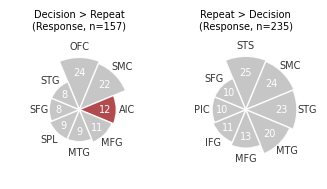

In [191]:
significant_delta['direction'] = np.where(
    significant_delta['delta'] > 0, 
    'Decision > Repeat', 
    'Repeat > Decision'
)

cm = 1 / 2.54
top_n = 8

# 先计算两边的最大值，用于统一 scale
max_count_global = 0
for direction in ['Decision > Repeat', 'Repeat > Decision']:
    subset = significant_delta[significant_delta['direction'] == direction]
    if not subset.empty:
        roi_counts = subset.groupby('roi')['channel'].nunique()
        max_count_global = max(max_count_global, roi_counts.max())

# 统一的最大半径
max_radius = np.sqrt(max_count_global)

fig, axes = plt.subplots(1, 2, figsize=(10*cm, 7*cm), subplot_kw={'projection': 'polar'})

for ax, direction in zip(axes, ['Decision > Repeat', 'Repeat > Decision']):
    subset = significant_delta[significant_delta['direction'] == direction]
    
    if subset.empty:
        ax.set_visible(False)
        continue
    
    roi_counts = subset.groupby('roi')['channel'].nunique().sort_values(ascending=False)
    main_rois = roi_counts.iloc[:top_n]
    
    values = main_rois.values
    labels = main_rois.index
    radii = np.sqrt(values)
    
    n = len(values)
    theta = np.linspace(0.0, 2 * np.pi, n, endpoint=False)
    width = 2 * np.pi / n
    
    colors = [red if label == 'AIC' else '#C0C0C0' for label in labels]
    
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    ax.bar(theta, radii, width=width, bottom=0.0, 
           color=colors, edgecolor='white', linewidth=1, alpha=0.9)
    
    # 统一半径范围
    ax.set_ylim(0, max_radius * 1.3)
    
    ax.grid(False)
    ax.spines['polar'].set_visible(False)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    
    for t, r, v, label in zip(theta, radii, values, labels):
        padding = max_radius * 0.2  # 用全局 max 来定 padding
        ax.text(t, r + padding, f"{label}", ha='center', va='center', fontsize=7, color='#333333')
        if r > 0.5:  # 只在足够大的 bar 里写数字
            ax.text(t, r * 0.7, f"{v}", ha='center', va='center', fontsize=7, color='white')
    
    # 加总数标注
    total = subset['channel'].nunique()
    ax.set_title(f'{direction}\n({phase.capitalize()}, n={total})', fontsize=7, pad=8)

# fig.savefig(f'../img/misc/piechart_direction_compare_{phase}.svg', dpi=300, bbox_inches='tight')
plt.show()

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


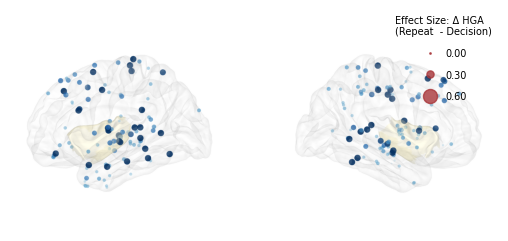

In [192]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree

labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',
    hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)


subset = significant_delta[(significant_delta.delta < 0)]
subset = subset[~subset.roi.isin(['LinG','GRect','PCun','LatV','iOccG','CollatAnt','OFC'])]
cord = subset[['x', 'y', 'z']].values
mean_delta = subset['delta'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# Color + size mapping
cmap = plt.cm.RdBu_r
max_abs = np.percentile(np.abs(mean_delta), 95)
max_abs = max(max_abs, 1e-6)
max_abs = 0.6
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

size_min, size_max = 1, 40
alpha_min, alpha_max = 0.2, 0.9

def val_to_size(v, vmax_abs, size_min, size_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return size_min + x * (size_max - size_min)

def val_to_alpha(v, vmax_abs, alpha_min, alpha_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return alpha_min + x * (alpha_max - alpha_min)

def build_valid_vertex_mask(labels, hemi, n_vertices):
    m = np.zeros(n_vertices, dtype=bool)
    for lab in labels:
        if lab.hemi == hemi:
            m[lab.vertices] = True
    return m

def add_projected_points(brain, hemi, coords, vals, tree, surf_coords, valid_vertex_mask):
    if coords.size == 0:
        return

    _, indices = tree.query(coords)
    projected = surf_coords[indices]
    keep = valid_vertex_mask[indices]

    if not keep.any():
        return

    for pt, v in zip(projected[keep], vals[keep]):
        cloud = pv.PolyData(pt.reshape(1, 3))
        color = cmap(norm(v))[:3]
        size = val_to_size(v, max_abs, size_min, size_max)
        alpha = val_to_alpha(v, max_abs, alpha_min, alpha_max)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=float(size),
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=float(alpha),
        )

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)
lh_valid_vertex = build_valid_vertex_mask(labels, 'lh', len(lh_coords_pial))

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)
rh_valid_vertex = build_valid_vertex_mask(labels, 'rh', len(rh_coords_pial))

if mask_lh.any():
    add_projected_points(
        lh_brain,
        'lh',
        cord[mask_lh],
        mean_delta[mask_lh],
        lh_tree,
        lh_coords_pial,
        lh_valid_vertex,
    )

if mask_rh.any():
    add_projected_points(
        rh_brain,
        'rh',
        cord[mask_rh],
        mean_delta[mask_rh],
        rh_tree,
        rh_coords_pial,
        rh_valid_vertex,
    )

insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

# acc_patterns = ['G_and_S_cingul-Mid-Ant','G_and_S_cingul-Mid-Ant',
#                 'G_and_S_cingul-Ant', 'G_and_S_cingul-Ant']

# for lab in labels:
#     if any(pattern in lab.name for pattern in acc_patterns):
#         if lab.hemi == 'lh':
#             lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
#         elif lab.hemi == 'rh':
#             rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)


for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]})
# plt.subplots_adjust(wspace=0.02)
ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")

example_values = [0, max_abs * 0.5, max_abs]
example_labels = ['0.00', f'{max_abs * 0.5:.2f}', f'{max_abs:.2f}']

legend_scale = 0.35

handles = []
for v, lab in zip(example_values, example_labels):
    # PyVista point_size 是像素；Matplotlib markersize 是 points
    ps_px = val_to_size(v, max_abs, size_min, size_max)
    ms_pt = ps_px * 72.0 / fig.dpi * legend_scale
    h = plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor=red,
        markeredgecolor=red,
        markersize=max(1.0, ms_pt),
        alpha=0.8,
        label=lab,
    )
    handles.append(h)

ax2.legend(
    handles=handles,
    title='Effect Size: Δ HGA\n(Repeat  - Decision)',
    loc='upper right',
    frameon=False,
    borderaxespad=0.2,
    handletextpad=0.6,
    labelspacing=1.2,
    fontsize=7,
    title_fontsize=7,
)

lh_brain.close()
rh_brain.close()
# fig.savefig(f'../img/misc/univarite_condition_difference_decision_{phase}.svg', dpi=300, bbox_inches='tight')

# Lexicality

In [159]:
ref = 'bipolar'
contrast_paths = []
for t in ['LexicalNoDelay']:
    contrast_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='univariate',
            # description='WordVsNonwordDecision',
            suffix='highgamma',
            check=False,
        ).match()
    )

print(f"Found {len(contrast_paths)} contrast files")

contrast_dfs = []
for path in tqdm(contrast_paths):
    df = pd.read_csv(path)
    df['subject'] = path.subject
    df['task'] = path.task
    df['description'] = path.description
    contrast_dfs.append(df)

dec_vs_rep = pd.concat(contrast_dfs, ignore_index=True)

# Merge ROI info from HGAs (channel + subject is unique key)
# Get unique channel metadata from HGAs
channel_meta = HGAs[['channel', 'roi', 'hemi', 'label', 'x', 'y', 'z']].drop_duplicates(subset='channel')
dec_vs_rep = dec_vs_rep.merge(channel_meta, on='channel', how='left')

# Exclude bad channels
dec_vs_rep = dec_vs_rep[~dec_vs_rep.channel.isin(exclude_chn)]

print(f"Total: {len(dec_vs_rep)} rows, {dec_vs_rep.subject.nunique()} subjects")
print(f"ROIs: {sorted(dec_vs_rep.roi.dropna().unique())}")


# take only the channel in HGAs
pick_chn = HGAs.channel.unique()
dec_vs_rep = dec_vs_rep[dec_vs_rep.channel.isin(pick_chn)]
dec_vs_rep = dec_vs_rep[dec_vs_rep.description != 'DecisionVsRepeat']

# --- remove electrodes with pre-0 significance in stimulus ---
pre0_bad = dec_vs_rep[
    (dec_vs_rep['phase'] == 'stimulus') &
    (dec_vs_rep['time'] < 0) &
    (dec_vs_rep['significant'] == True) &
    (dec_vs_rep['mask'] == True)
]['channel'].unique()

print(f"Channels with pre-0 significant activity in stimulus: {len(pre0_bad)}")

# 全局删除这些电极（所有 phase / condition 都删）
dec_vs_rep = dec_vs_rep[~dec_vs_rep['channel'].isin(pre0_bad)].copy()

print(f"Remaining channels: {dec_vs_rep['channel'].nunique()}")

# map description
dec_vs_rep['description'] = dec_vs_rep['description'].map({
    'WordVsNonwordDecision': 'Decision',
    'WordVsNonwordRepeat': 'Repeat',
})
dec_vs_rep.head()

Found 75 contrast files


100%|██████████| 75/75 [00:01<00:00, 53.46it/s]


Total: 1746240 rows, 25 subjects
ROIs: ['ACC', 'AG', 'AIC', 'Amyg', 'CC_Anterior', 'CGs', 'Calcarine', 'Cb', 'Central', 'CollatAnt', 'FuG', 'FuGs', 'GRect', 'HG', 'Hipp', 'IFG', 'IFGs', 'IPL', 'ITG', 'InfLatV', 'LinG', 'LinGs', 'MFG', 'MFGs', 'MTG', 'OFC', 'OFCs', 'OPC', 'OccS', 'PCC', 'PCun', 'PCuns', 'PIC', 'Paracentral', 'PhG', 'Put', 'SFG', 'SFGs', 'SMC', 'SMG', 'SPL', 'STG', 'STS', 'Sylvian', 'TP', 'Thal', 'VDC', 'dACC', 'iOccGs', 'mOccG']
Channels with pre-0 significant activity in stimulus: 96
Remaining channels: 995


,channel,time,mask,p,mean_a,mean_b,mean_diff,significant,direction,phase,subject,task,description,roi,hemi,label,x,y,z
8320,D0024_LMST3-4,-1.000000,0,0.476305,0.127472,0.063804,0.063667,True,Nonword,response,D0024,LexicalNoDelay,Decision,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326
8321,D0024_LMST3-4,-0.992188,0,0.133973,0.131890,-0.098066,0.229956,True,Nonword,response,D0024,LexicalNoDelay,Decision,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326
8322,D0024_LMST3-4,-0.984375,0,0.032394,0.125795,-0.243085,0.368879,True,Nonword,response,D0024,LexicalNoDelay,Decision,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326
8323,D0024_LMST3-4,-0.976562,0,0.013197,0.124517,-0.334009,0.458526,True,Nonword,response,D0024,LexicalNoDelay,Decision,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326
8324,D0024_LMST3-4,-0.968750,0,0.009998,0.128668,-0.355308,0.483976,True,Nonword,response,D0024,LexicalNoDelay,Decision,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326


In [160]:
# --- post-hoc duration filter for significant mask ---
min_cluster_s = 0.10  # 100 ms

# 备份原始标记
dec_vs_rep['mask_raw'] = dec_vs_rep['mask'].astype(bool)
dec_vs_rep['significant_raw'] = dec_vs_rep['significant'].astype(bool)

def apply_min_duration_filter(g, min_s=0.10):
    g = g.sort_values('time').copy()

    sig = (g['mask_raw'].values) & (g['significant_raw'].values)
    t = g['time'].values
    keep = np.zeros(len(g), dtype=bool)

    # 时间分辨率（用于把单点时长按 1 个采样间隔估计）
    tu = np.unique(t)
    if len(tu) > 1:
        dt = np.median(np.diff(tu))
    else:
        dt = 0.0

    idx = np.where(sig)[0]
    if idx.size > 0:
        # 先按索引连续性分段
        breaks = np.where(np.diff(idx) > 1)[0] + 1
        runs = np.split(idx, breaks)

        # 再按时间连续性切分（避免采样缺口误连）
        final_runs = []
        for run in runs:
            if len(run) == 1:
                final_runs.append(run)
                continue
            sub_breaks = np.where(np.diff(t[run]) > (1.5 * dt if dt > 0 else np.inf))[0] + 1
            final_runs.extend(np.split(run, sub_breaks))

        # 保留时长 >= min_s 的段
        for run in final_runs:
            if len(run) == 0:
                continue
            dur = (t[run[-1]] - t[run[0]]) + dt
            if dur >= min_s:
                keep[run] = True

    g['mask'] = keep
    g['significant'] = bool(keep.any())
    return g

# 按 每个 subject×task×description×phase×channel 独立过滤
group_cols = ['subject', 'task', 'description', 'phase', 'channel']
dec_vs_rep = (
    dec_vs_rep
    .groupby(group_cols, group_keys=False)
    .apply(apply_min_duration_filter, min_s=min_cluster_s)
)

print("Before filter: significant channels =", dec_vs_rep.loc[dec_vs_rep['significant_raw'], 'channel'].nunique())
print("After  filter: significant channels =", dec_vs_rep.loc[dec_vs_rep['significant'], 'channel'].nunique())

Before filter: significant channels = 317
After  filter: significant channels = 302


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_2064491/1554030150.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(apply_min_duration_filter, min_s=min_cluster_s)


In [164]:
# ==========================================
# NEW VERSION: Use mean_diff directly from CSV
# ==========================================
task_name = 'LexicalDelay'

phase = ['stimulus','delay','response','go']
# phase = ['delay']
desc = 'Repeat'
sig_points = dec_vs_rep[
    # (dec_vs_rep.task == task_name) & 
    (dec_vs_rep.description == desc) & 
    (dec_vs_rep.significant == True) &
    (dec_vs_rep['mask'] == True) &
    (dec_vs_rep.phase.isin(phase))
    # (dec_vs_rep.time<1) &   
    # (dec_vs_rep.time>0)
]

# 2. 对每个 channel 和 phase，计算显著时间窗口内的平均 delta (mean_diff)
# 因为 mean_diff 已经是 Decision - Repeat 了，直接求平均即可
# 合并 ROI：把沟(sulcus, 带s后缀)合并到对应的回(gyrus)
roi_merge = {
    'MFGs': 'MFG',
    'OFCs': 'OFC',
    'SFGs': 'SFG',
    'IFGs': 'IFG',
    'CGs': 'CG',
    'PCuns': 'PCun',
    'LinGs': 'LinG',
    'iOccGs': 'iOccG',
}
sig_points['roi'] = sig_points['roi'].replace(roi_merge)

significant_delta = sig_points.groupby(
    ['channel', 'phase', 'roi', 'hemi', 'label', 'x', 'y', 'z']
)['mean_diff'].mean().reset_index()

significant_delta = significant_delta.rename(columns={'mean_diff': 'delta'})

print(f"Significant electrodes: {significant_delta.channel.nunique()}")
print(significant_delta.groupby(['phase', 'roi'])['channel'].nunique())
significant_delta.head()


Significant electrodes: 114
phase     roi      
response  AG            3
          AIC           2
          Calcarine     1
          Central       1
          Hipp          2
          IFG           4
          ITG           2
          LinG          5
          MFG           9
          MTG           6
          OFC           9
          PCC           1
          PIC           2
          Put           2
          SFG           6
          SMC          10
          SMG           1
          SPL           3
          STG           6
          STS           6
          Sylvian       1
          TP            1
          Thal          2
          dACC          3
stimulus  AG            1
          CollatAnt     1
          GRect         1
          HG            1
          Hipp          1
          IFG           4
          ITG           1
          LinG          1
          MFG           8
          MTG           6
          OFC           2
          SFG           4
          SMC   

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_2064491/4197029067.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sig_points['roi'] = sig_points['roi'].replace(roi_merge)


,channel,phase,roi,hemi,label,x,y,z,delta
0,D0024_LMST3-4,response,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326,0.467772
1,D0024_LMST3-4,stimulus,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326,0.407130
2,D0024_LTG10-11,response,STG,L,ctx_lh_G_temp_sup-Plan_polar,-57.556619,13.428461,-13.889566,-0.427913
3,D0024_LTG11-12,stimulus,STG,L,ctx_lh_G_temp_sup-Lateral,-63.429294,2.621261,-8.131305,-0.468584
4,D0026_RPG27-28,stimulus,mOccG,R,ctx_rh_G_occipital_middle,37.196486,-85.332986,24.513634,-0.399844


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


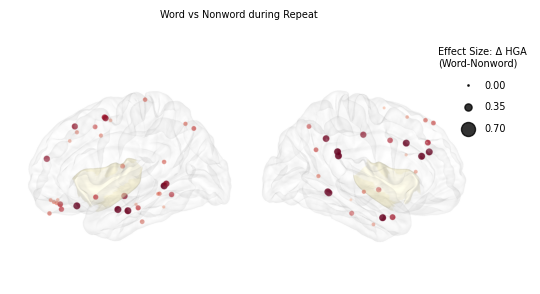

In [166]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree

labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',
    hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)

# direction = 'nwgt'
subset = significant_delta[(significant_delta.delta > 0)]
# subset = significant_delta[(significant_delta.delta > 0) & ((significant_delta.roi.isin(['ACC'])))]
# subset = significant_delta[(significant_delta.roi=='AIC')]
# subset = significant_delta

cord = subset[['x', 'y', 'z']].values
mean_delta = subset['delta'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# Color + size mapping
cmap = plt.cm.RdBu_r
max_abs = np.percentile(np.abs(mean_delta), 95)
max_abs = max(max_abs, 1e-6)
max_abs = 0.7
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

size_min, size_max = 1, 40
alpha_min, alpha_max = 0.2, 0.9

def val_to_size(v, vmax_abs, size_min, size_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return size_min + x * (size_max - size_min)

def val_to_alpha(v, vmax_abs, alpha_min, alpha_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return alpha_min + x * (alpha_max - alpha_min)

def build_valid_vertex_mask(labels, hemi, n_vertices):
    m = np.zeros(n_vertices, dtype=bool)
    for lab in labels:
        if lab.hemi == hemi:
            m[lab.vertices] = True
    return m

def add_projected_points(brain, hemi, coords, vals, tree, surf_coords, valid_vertex_mask):
    if coords.size == 0:
        return

    _, indices = tree.query(coords)
    projected = surf_coords[indices]
    keep = valid_vertex_mask[indices]

    if not keep.any():
        return

    for pt, v in zip(projected[keep], vals[keep]):
        cloud = pv.PolyData(pt.reshape(1, 3))
        color = cmap(norm(v))[:3]
        size = val_to_size(v, max_abs, size_min, size_max)
        alpha = val_to_alpha(v, max_abs, alpha_min, alpha_max)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=float(size),
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=float(alpha),
        )

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)
lh_valid_vertex = build_valid_vertex_mask(labels, 'lh', len(lh_coords_pial))

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)
rh_valid_vertex = build_valid_vertex_mask(labels, 'rh', len(rh_coords_pial))

if mask_lh.any():
    add_projected_points(
        lh_brain,
        'lh',
        cord[mask_lh],
        mean_delta[mask_lh],
        lh_tree,
        lh_coords_pial,
        lh_valid_vertex,
    )

if mask_rh.any():
    add_projected_points(
        rh_brain,
        'rh',
        cord[mask_rh],
        mean_delta[mask_rh],
        rh_tree,
        rh_coords_pial,
        rh_valid_vertex,
    )

insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

# acc_patterns = ['G_and_S_cingul-Mid-Ant','G_and_S_cingul-Mid-Ant',
#                 'G_and_S_cingul-Ant', 'G_and_S_cingul-Ant']

# for lab in labels:
#     if any(pattern in lab.name for pattern in acc_patterns):
#         if lab.hemi == 'lh':
#             lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
#         elif lab.hemi == 'rh':
#             rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)


for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]})
plt.subplots_adjust(wspace=-0.1)
ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")

example_values = [0, max_abs * 0.5, max_abs]
example_labels = ['0.00', f'{max_abs * 0.5:.2f}', f'{max_abs:.2f}']

legend_scale = 0.35

handles = []
for v, lab in zip(example_values, example_labels):
    # PyVista point_size 是像素；Matplotlib markersize 是 points
    ps_px = val_to_size(v, max_abs, size_min, size_max)
    ms_pt = ps_px * 72.0 / fig.dpi * legend_scale
    h = plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor='black',
        markeredgecolor='black',
        markersize=max(1.0, ms_pt),
        alpha=0.8,
        label=lab,
    )
    handles.append(h)

ax2.legend(
    handles=handles,
    title='Effect Size: Δ HGA\n(Word-Nonword)',
    loc='upper right',
    frameon=False,
    bbox_to_anchor=(1.2, 1),   
    borderaxespad=0.2,
    handletextpad=0.6,
    labelspacing=1.2,
    fontsize=7,
    title_fontsize=7,
)

plt.suptitle(f'Word vs Nonword during {desc}', fontsize=7)
lh_brain.close()
rh_brain.close()
# fig.savefig(f'../img/misc/univariate_wnw_{desc}_{direction}.svg', dpi=300, bbox_inches='tight')

In [ ]:
# ==========================================
# 2×3 electrode classification
# ==========================================
# 1) 先分别筛 Decision / Repeat 的显著点
phase_list = ['stimulus', 'delay', 'response', 'go']
time_range = (-1, 1)
# phase_list = ['stimulus']
base = dec_vs_rep[
    (dec_vs_rep.significant == True) &
    (dec_vs_rep['mask'] == True) &
    (dec_vs_rep.phase.isin(phase_list)) &
    (dec_vs_rep.time > time_range[0]) &
    (dec_vs_rep.time < time_range[1])
].copy()

# ROI merge
roi_merge = {
    'MFGs': 'MFG', 'OFCs': 'OFC', 'SFGs': 'SFG', 'IFGs': 'IFG',
    'CGs': 'CG', 'PCuns': 'PCun', 'LinGs': 'LinG', 'iOccGs': 'iOccG',
}
base['roi'] = base['roi'].replace(roi_merge)

# 2) 按 channel + description 聚合 mean_diff
ch_desc = base.groupby(['channel', 'description', 'roi', 'hemi', 'x', 'y', 'z'], as_index=False).agg(
    delta=('mean_diff', 'mean')
)

# 3) 拆成 Decision / Repeat 两张表
dec_df = ch_desc[ch_desc.description == 'Decision'][['channel', 'delta']].rename(columns={'delta': 'delta_dec'})
rep_df = ch_desc[ch_desc.description == 'Repeat'][['channel', 'delta']].rename(columns={'delta': 'delta_rep'})

# 4) 合并，标记每个 channel 在哪些条件下显著
ch_meta = ch_desc[['channel', 'roi', 'hemi', 'x', 'y', 'z']].drop_duplicates(subset='channel')
ch_class = ch_meta.merge(dec_df, on='channel', how='left').merge(rep_df, on='channel', how='left')

# 5) 定义 overlap 类别
def get_overlap(row):
    has_dec = not np.isnan(row['delta_dec'])
    has_rep = not np.isnan(row['delta_rep'])
    if has_dec and has_rep:
        return 'Both'
    elif has_dec:
        return 'Decision_only'
    elif has_rep:
        return 'Repeat_only'
    else:
        return 'None'

ch_class['overlap'] = ch_class.apply(get_overlap, axis=1)

# 6) 定义方向（用 Decision 优先，如果只有 Repeat 则用 Repeat）
def get_direction(row):
    d = row['delta_dec'] if not np.isnan(row.get('delta_dec', np.nan)) else row.get('delta_rep', np.nan)
    if np.isnan(d):
        return 'None'
    return 'wgt' if d > 0 else 'nwgt'

ch_class['direction'] = ch_class.apply(get_direction, axis=1)

# 7) 合成 6 类标签
ch_class['group'] = ch_class['direction'] + '_' + ch_class['overlap']

# 合并 delta：Both 取平均，otherwise 取有值的那个
ch_class['delta'] = ch_class.apply(
    lambda r: np.nanmean([r['delta_dec'], r['delta_rep']]) 
              if r['overlap'] == 'Both' 
              else (r['delta_dec'] if not np.isnan(r['delta_dec']) else r['delta_rep']),
    axis=1
)

# 8) 去掉 None
ch_class = ch_class[ch_class['overlap'] != 'None']

ch_class = ch_class[~ch_class.roi.isin([
    'LatV' ,'InfLatV','Cb',
    'Hipp','Amyg','Put','Thal',
    'Sylvian','Central','CollatAnt',
    'OccS','mOccG','Calcarine','iOccG','LinG'
])]
print(ch_class.groupby(['direction', 'overlap'])['channel'].nunique())
ch_class.head()

direction  overlap      
nwgt       Both              36
           Decision_only    118
           Repeat_only       51
wgt        Both              54
           Decision_only    196
           Repeat_only       76
Name: channel, dtype: int64


,channel,roi,hemi,x,y,z,delta_dec,delta_rep,overlap,direction,group,delta
0,D0023_R1MF1-2,dACC,R,9.295536,5.962643,32.639046,NaN,0.351547,Repeat_only,wgt,wgt_Repeat_only,0.351547
1,D0023_R1MF11-12,IFG,R,44.886760,2.823622,35.046768,NaN,-0.553803,Repeat_only,nwgt,nwgt_Repeat_only,-0.553803
2,D0023_R2IF1-2,PIC,R,33.089530,-8.192050,18.614382,-0.374242,NaN,Decision_only,nwgt,nwgt_Decision_only,-0.374242
3,D0023_R2IF2-3,PIC,R,36.686262,-8.172090,19.151989,NaN,-0.437433,Repeat_only,nwgt,nwgt_Repeat_only,-0.437433
4,D0023_R2MF10-11,SMC,R,40.025482,-8.423863,36.077959,-0.402350,NaN,Decision_only,nwgt,nwgt_Decision_only,-0.402350


In [173]:
ch_class.group.unique()

array(['wgt_Repeat_only', 'nwgt_Repeat_only', 'nwgt_Decision_only',
       'wgt_Decision_only', 'wgt_Both', 'nwgt_Both'], dtype=object)

In [174]:
ch_class.roi.unique()

array(['dACC', 'IFG', 'PIC', 'SMC', 'SFG', 'AG', 'PCC', 'CG', 'ITG',
       'STG', 'SMG', 'MTG', 'AIC', 'MFG', 'STS', 'FuG', 'FuGs',
       'Paracentral', 'HG', 'OFC', 'ACC', 'SPL', 'PCun', 'PhG', 'IPL',
       'GRect', 'TP'], dtype=object)

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


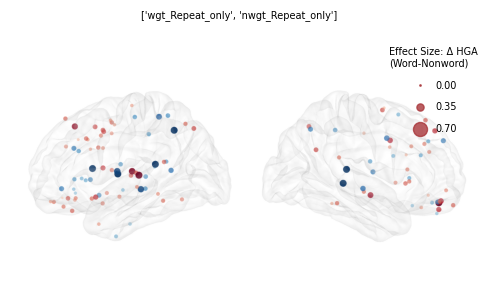

In [184]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree

labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',
    hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)

# group = ['nwgt_Both','wgt_Both']
group = ['wgt_Repeat_only','nwgt_Repeat_only']
# group = ['nwgt_Decision_only','wgt_Decision_only']

subset = ch_class[ch_class.group.isin(group)]
# subset = significant_delta[(significant_delta.delta > 0) & ((significant_delta.roi.isin(['ACC'])))]
# subset = significant_delta[(significant_delta.roi=='AIC')]
# subset = significant_delta

cord = subset[['x', 'y', 'z']].values
mean_delta = subset['delta'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# Color + size mapping
cmap = plt.cm.RdBu_r
max_abs = np.percentile(np.abs(mean_delta), 95)
max_abs = max(max_abs, 1e-6)
max_abs = 0.7
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

size_min, size_max = 1, 40
alpha_min, alpha_max = 0.2, 0.9

def val_to_size(v, vmax_abs, size_min, size_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return size_min + x * (size_max - size_min)

def val_to_alpha(v, vmax_abs, alpha_min, alpha_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return alpha_min + x * (alpha_max - alpha_min)

def build_valid_vertex_mask(labels, hemi, n_vertices):
    m = np.zeros(n_vertices, dtype=bool)
    for lab in labels:
        if lab.hemi == hemi:
            m[lab.vertices] = True
    return m

def add_projected_points(brain, hemi, coords, vals, tree, surf_coords, valid_vertex_mask):
    if coords.size == 0:
        return

    _, indices = tree.query(coords)
    projected = surf_coords[indices]
    keep = valid_vertex_mask[indices]

    if not keep.any():
        return

    for pt, v in zip(projected[keep], vals[keep]):
        cloud = pv.PolyData(pt.reshape(1, 3))
        color = cmap(norm(v))[:3]
        size = val_to_size(v, max_abs, size_min, size_max)
        alpha = val_to_alpha(v, max_abs, alpha_min, alpha_max)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=float(size),
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=float(alpha),
        )

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)
lh_valid_vertex = build_valid_vertex_mask(labels, 'lh', len(lh_coords_pial))

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)
rh_valid_vertex = build_valid_vertex_mask(labels, 'rh', len(rh_coords_pial))

if mask_lh.any():
    add_projected_points(
        lh_brain,
        'lh',
        cord[mask_lh],
        mean_delta[mask_lh],
        lh_tree,
        lh_coords_pial,
        lh_valid_vertex,
    )

if mask_rh.any():
    add_projected_points(
        rh_brain,
        'rh',
        cord[mask_rh],
        mean_delta[mask_rh],
        rh_tree,
        rh_coords_pial,
        rh_valid_vertex,
    )

# insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
#                    'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']
# for lab in labels:
#     if any(pattern in lab.name for pattern in insula_patterns):
#         if lab.hemi == 'lh':
#             lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
#         elif lab.hemi == 'rh':
#             rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

# acc_patterns = ['G_and_S_cingul-Mid-Ant','G_and_S_cingul-Mid-Ant',
#                 'G_and_S_cingul-Ant', 'G_and_S_cingul-Ant']

# for lab in labels:
#     if any(pattern in lab.name for pattern in acc_patterns):
#         if lab.hemi == 'lh':
#             lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
#         elif lab.hemi == 'rh':
#             rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)


for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]})
plt.subplots_adjust(wspace=-0.1)
ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")

example_values = [0, max_abs * 0.5, max_abs]
example_labels = ['0.00', f'{max_abs * 0.5:.2f}', f'{max_abs:.2f}']

legend_scale = 0.35

handles = []
for v, lab in zip(example_values, example_labels):
    # PyVista point_size 是像素；Matplotlib markersize 是 points
    ps_px = val_to_size(v, max_abs, size_min, size_max)
    ms_pt = ps_px * 72.0 / fig.dpi * legend_scale
    h = plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor=red,
        markeredgecolor=red,
        markersize=max(1.0, ms_pt),
        alpha=0.8,
        label=lab,
    )
    handles.append(h)

ax2.legend(
    handles=handles,
    title='Effect Size: Δ HGA\n(Word-Nonword)',
    loc='upper right',
    frameon=False,
    borderaxespad=0.2,
    handletextpad=0.6,
    labelspacing=1.2,
    fontsize=7,
    title_fontsize=7,
)

plt.suptitle(f'{group}', fontsize=7)
lh_brain.close()
rh_brain.close()
fig.savefig(f'../img/misc/univariate_{group}.svg', dpi=300, bbox_inches='tight')

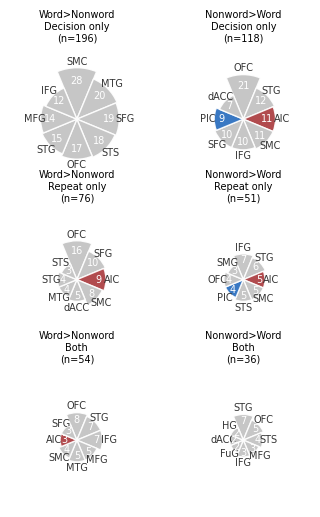

group
wgt_Decision_only     196
nwgt_Decision_only    118
wgt_Repeat_only        76
nwgt_Repeat_only       51
wgt_Both               54
nwgt_Both              36
Name: channel, dtype: int64


In [181]:

cm = 1 / 2.54
top_n = 8

# 用你在 Cell 18 生成的 ch_class
plot_df = ch_class.copy()

group_order = [
    "wgt_Decision_only","nwgt_Decision_only",
    "wgt_Repeat_only","nwgt_Repeat_only", 
    "wgt_Both","nwgt_Both",
]

group_title = {
    "wgt_Decision_only": "Word>Nonword\nDecision only",
    "wgt_Repeat_only":   "Word>Nonword\nRepeat only",
    "wgt_Both":          "Word>Nonword\nBoth",
    "nwgt_Decision_only":"Nonword>Word\nDecision only",
    "nwgt_Repeat_only":  "Nonword>Word\nRepeat only",
    "nwgt_Both":         "Nonword>Word\nBoth",
}

# 先算全局最大，统一半径尺度
max_count_global = 0
for g in group_order:
    sub = plot_df[plot_df["group"] == g]
    if sub.empty:
        continue
    roi_counts = sub.groupby("roi")["channel"].nunique()
    if len(roi_counts) > 0:
        max_count_global = max(max_count_global, roi_counts.max())

max_radius = np.sqrt(max_count_global) if max_count_global > 0 else 1.0

fig, axes = plt.subplots(
    3, 2, figsize=(10 * cm, 15 * cm), subplot_kw={"projection": "polar"}
)
axes = axes.ravel()

for ax, g in zip(axes, group_order):
    sub = plot_df[plot_df["group"] == g]

    if sub.empty:
        ax.set_visible(False)
        continue

    roi_counts = sub.groupby("roi")["channel"].nunique().sort_values(ascending=False)
    main_rois = roi_counts.iloc[:top_n]

    values = main_rois.values
    labels = main_rois.index
    radii = np.sqrt(values)

    n = len(values)
    theta = np.linspace(0.0, 2 * np.pi, n, endpoint=False)
    width = 2 * np.pi / n if n > 0 else 2 * np.pi

    colors = []
    for lab in labels:
        if lab == "AIC":
            colors.append(red)
        elif lab == "PIC":
            colors.append(blue)
        else:
            colors.append("#C0C0C0")

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.bar(
        theta, radii, width=width, bottom=0.0,
        color=colors, edgecolor="white", linewidth=1, alpha=0.9
    )

    ax.set_ylim(0, max_radius * 1.3)
    ax.grid(False)
    ax.spines["polar"].set_visible(False)
    ax.set_yticklabels([])
    ax.set_xticklabels([])

    for t, r, v, lab in zip(theta, radii, values, labels):
        padding = max_radius * 0.12
        ax.text(t, r + padding, f"{lab}", ha="center", va="center", fontsize=7, color="#333333")
        if r > 0.45:
            ax.text(t, r * 0.75, f"{v}", ha="center", va="center", fontsize=7, color="white")

    n_elecs = sub["channel"].nunique()
    ax.set_title(f"{group_title[g]}\n(n={n_elecs})", fontsize=7, pad=8)

plt.show()

fig.savefig("../img/misc/rose_word_nonword_groups.svg", dpi=300, bbox_inches="tight")

print(
    plot_df.groupby("group")["channel"].nunique()
           .reindex(group_order)
           .fillna(0)
           .astype(int)
)

# Cross Task

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'LexicalNoDelay',
        'LexicalDelay',
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'
HGAs.head()

100%|██████████| 497/497 [00:11<00:00, 43.12it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 288960
PIC electrode count: 271360


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


In [6]:
# ==========================================
# Load cross-task contrast results (Delay vs NoDelay)
# ==========================================
ref = 'bipolar'
contrast_paths = BIDSPath(
    root=f'../results/CrossTask({ref})',
    datatype='univariate',
    task='CrossTask',
    description='DelayVsNoDelay',
    suffix='highgamma',
    check=False,
).match()

print(f"Found {len(contrast_paths)} cross-task contrast files")

contrast_dfs = []
for path in tqdm(contrast_paths):
    df = pd.read_csv(path)

    # keep in-file columns (description=Decision/Repeat), avoid overwrite
    df['subject'] = path.subject
    df['task_file'] = path.task                 # CrossTask
    df['contrast_file'] = path.description      # DelayVsNoDelay

    contrast_dfs.append(df)

cross_task = pd.concat(contrast_dfs, ignore_index=True)

# Merge ROI info
channel_meta = HGAs[['channel', 'roi', 'hemi', 'label', 'x', 'y', 'z']].drop_duplicates(subset='channel')
cross_task = cross_task.merge(channel_meta, on='channel', how='left')

# Exclude bad channels
cross_task = cross_task[~cross_task.channel.isin(exclude_chn)]

# Optional: take only channels in HGAs
pick_chn = HGAs.channel.unique()
cross_task = cross_task[cross_task.channel.isin(pick_chn)]

print(f"Total rows: {len(cross_task)}")
print(f"Subjects: {cross_task.subject.nunique()}")
print(f"Descriptions in data: {sorted(cross_task['description'].dropna().unique())}")  # Decision / Repeat
print(f"Contrast file tags: {sorted(cross_task['contrast_file'].dropna().unique())}")  # DelayVsNoDelay
print(f"ROIs: {sorted(cross_task.roi.dropna().unique())}")

cross_task.head()

Found 20 cross-task contrast files


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 47.44it/s]


Total rows: 464000
Subjects: 20
Descriptions in data: ['Decision', 'Repeat']
Contrast file tags: ['DelayVsNoDelay']
ROIs: ['ACC', 'AG', 'AIC', 'Amyg', 'CGs', 'Calcarine', 'Cb', 'Central', 'CollatAnt', 'FuG', 'FuGs', 'GRect', 'Hipp', 'IFG', 'IFGs', 'IPL', 'ITG', 'InfLatV', 'LinG', 'LinGs', 'MFG', 'MFGs', 'MTG', 'OFC', 'OFCs', 'OPC', 'OccS', 'PCC', 'PCun', 'PCuns', 'PIC', 'Paracentral', 'PhG', 'Put', 'SFG', 'SFGs', 'SMC', 'SMG', 'SPL', 'STG', 'STS', 'Sylvian', 'TP', 'Thal', 'dACC', 'iOccGs', 'mOccG']


,channel,time,mask,p,mean_a,mean_b,mean_diff,peak_diff,significant,direction,...,phase,subject,task_file,contrast_file,roi,hemi,label,x,y,z
0,D0024_LMST3-4,-1.000000,1,0.003999,-0.139820,0.114947,-0.254767,-0.101854,True,NoDelay,...,response,D0024,CrossTask,DelayVsNoDelay,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326
1,D0024_LMST3-4,-0.992188,1,0.009598,-0.125218,0.086653,-0.211871,-0.101854,True,NoDelay,...,response,D0024,CrossTask,DelayVsNoDelay,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326
2,D0024_LMST3-4,-0.984375,1,0.015197,-0.125148,0.053228,-0.178377,-0.101854,True,NoDelay,...,response,D0024,CrossTask,DelayVsNoDelay,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326
3,D0024_LMST3-4,-0.976562,1,0.011198,-0.142079,0.034315,-0.176394,-0.101854,True,NoDelay,...,response,D0024,CrossTask,DelayVsNoDelay,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326
4,D0024_LMST3-4,-0.968750,1,0.007199,-0.166690,0.033460,-0.200150,-0.101854,True,NoDelay,...,response,D0024,CrossTask,DelayVsNoDelay,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326


In [7]:
# ==========================================
# CrossTask: significant electrodes (Delay vs NoDelay)
# ==========================================
phase = ['response']          # 你现在只做 response
desc = 'Decision'             # 可改成 'Repeat'

sig_points = cross_task[
    (cross_task.description == desc) &
    (cross_task.significant == True) &
    (cross_task['mask'] == True) &
    (cross_task.phase.isin(phase))
].copy()

# ROI merge（保持和你之前一致）
roi_merge = {
    'MFGs': 'MFG',
    'OFCs': 'OFC',
    'SFGs': 'SFG',
    'IFGs': 'IFG',
    'CGs': 'CG',
    'PCuns': 'PCun',
    'LinGs': 'LinG',
    'iOccGs': 'iOccG',
}
sig_points['roi'] = sig_points['roi'].replace(roi_merge)

# 每个电极聚合：mean_diff + peak_diff
# mean_diff: 时间点平均
# peak_diff: 在你导出的csv里是按channel常数，这里用 first 最稳
significant_delta = sig_points.groupby(
    ['channel', 'roi', 'hemi', 'label', 'x', 'y', 'z'],
    as_index=False
).agg(
    delta_mean=('mean_diff', 'mean'),
    delta_peak=('peak_diff', 'first'),
    p_min=('p', 'min'),
)

# 方向标签（基于 mean_diff）
significant_delta['direction'] = np.where(
    significant_delta['delta_mean'] > 0,
    'Delay>NoDelay',
    'NoDelay>Delay'
)

print(f"[{desc}] Significant electrodes: {significant_delta.channel.nunique()}")
print(significant_delta.groupby(['roi'])['channel'].nunique().sort_values(ascending=False).head(15))
significant_delta.head()

[Decision] Significant electrodes: 491
roi
OFC     54
STS     53
SFG     36
SMC     35
MFG     34
STG     29
MTG     27
IFG     23
dACC    16
ACC     16
PIC     16
LinG    15
AIC     15
Hipp    15
Thal    13
Name: channel, dtype: int64


,channel,roi,hemi,label,x,y,z,delta_mean,delta_peak,p_min,direction
0,D0024_LMST3-4,ITG,L,ctx_lh_G_temporal_inf,-44.448854,-26.918044,-32.620326,-0.289782,-0.101854,0.000400,NoDelay>Delay
1,D0024_LOF1-2,OFC,L,ctx_lh_G_orbital,-8.479743,30.393553,-27.559950,0.438606,1.395245,0.000400,Delay>NoDelay
2,D0024_LOF3-4,OFC,L,ctx_lh_G_orbital,-29.806176,31.473703,-22.186615,-0.390630,1.960562,0.001200,NoDelay>Delay
3,D0024_LPST2-3,FuG,L,ctx_lh_G_oc-temp_lat-fusifor,-31.763535,-40.022416,-23.354454,-0.315229,-0.557922,0.000800,NoDelay>Delay
4,D0024_LTG10-11,STG,L,ctx_lh_G_temp_sup-Plan_polar,-57.556619,13.428461,-13.889566,-0.250244,0.829460,0.003599,NoDelay>Delay


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


2026-03-19 20:12:17.267 (  31.170s) [    7FE01E8B9740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


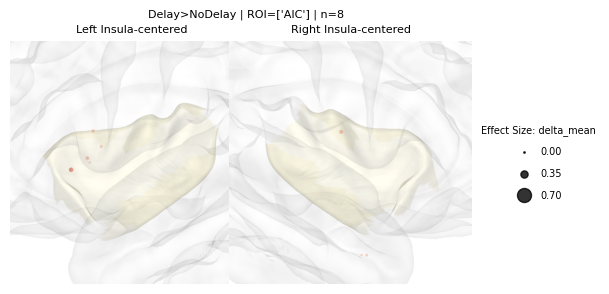

In [11]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree
from matplotlib.lines import Line2D

# -----------------------------
# Settings
# -----------------------------
cm = 1 / 2.54
direction = 'Delay>NoDelay'      # or 'NoDelay>Delay'
roi_filter = ['AIC']             # [] for all ROIs, or e.g. ['AIC', 'PIC']
value_col = 'delta_mean'         # 'delta_mean' or 'delta_peak'
max_abs = 0.7                    # fixed color scale
save_fig = False

# -----------------------------
# Labels / surfaces
# -----------------------------
labels = mne.read_labels_from_annot(
    subject='fsaverage',
    parc='aparc.a2009s',
    hemi='both',
    subjects_dir=recon_dir
)

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
lh_tree = cKDTree(lh_coords_pial)
rh_tree = cKDTree(rh_coords_pial)

# -----------------------------
# Build subset
# -----------------------------
subset = significant_delta[significant_delta.direction == direction].copy()
if len(roi_filter) > 0:
    subset = subset[subset.roi.isin(roi_filter)].copy()

if subset.empty:
    raise ValueError("subset is empty. Check direction / roi_filter.")

cord = subset[['x', 'y', 'z']].values
vals = subset[value_col].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# -----------------------------
# Brain objects
# -----------------------------
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600 * cm, 600 * cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600 * cm, 600 * cm)
)

# -----------------------------
# Color/size mapping
# -----------------------------
cmap = plt.cm.RdBu_r
max_abs = max(max_abs, 1e-6)
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

size_min, size_max = 1, 40
alpha_min, alpha_max = 0.2, 0.9

def val_to_size(v, vmax_abs, size_min, size_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return size_min + x * (size_max - size_min)

def val_to_alpha(v, vmax_abs, alpha_min, alpha_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return alpha_min + x * (alpha_max - alpha_min)

def build_valid_vertex_mask(labels, hemi, n_vertices):
    m = np.zeros(n_vertices, dtype=bool)
    for lab in labels:
        if lab.hemi == hemi:
            m[lab.vertices] = True
    return m

def add_projected_points(brain, coords, values, tree, surf_coords, valid_vertex_mask):
    if coords.size == 0:
        return
    _, indices = tree.query(coords)
    projected = surf_coords[indices]
    keep = valid_vertex_mask[indices]
    if not keep.any():
        return

    for pt, v in zip(projected[keep], values[keep]):
        cloud = pv.PolyData(pt.reshape(1, 3))
        color = cmap(norm(v))[:3]
        size = val_to_size(v, max_abs, size_min, size_max)
        alpha = val_to_alpha(v, max_abs, alpha_min, alpha_max)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=float(size),
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=float(alpha),
        )

lh_valid_vertex = build_valid_vertex_mask(labels, 'lh', len(lh_coords_pial))
rh_valid_vertex = build_valid_vertex_mask(labels, 'rh', len(rh_coords_pial))

if mask_lh.any():
    add_projected_points(
        lh_brain, cord[mask_lh], vals[mask_lh],
        lh_tree, lh_coords_pial, lh_valid_vertex
    )

if mask_rh.any():
    add_projected_points(
        rh_brain, cord[mask_rh], vals[mask_rh],
        rh_tree, rh_coords_pial, rh_valid_vertex
    )

# -----------------------------
# (Optional) highlight insula labels
# -----------------------------
insula_patterns = [
    'G_insular_short',
    'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant',
    'S_circular_insula_inf',
    'S_circular_insula_sup'
]
insula_color = (0.95, 0.90, 0.65)

for lab in labels:
    if any(p in lab.name for p in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.45)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.45)

# -----------------------------
# Compute insula centers for camera
# -----------------------------
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if len(vertices) == 0:
        return None
    return pial_coords[np.array(vertices)].mean(axis=0)

lh_insula_center = get_insula_center(labels, 'lh', lh_coords_pial)
rh_insula_center = get_insula_center(labels, 'rh', rh_coords_pial)

# Insula-centered lateral views
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0,   elevation=90, distance=180, focalpoint=rh_insula_center)

for brain in (lh_brain, rh_brain):
    brain._renderer.plotter.window_size = [1400, 1400]

# -----------------------------
# Plot screenshots
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm), gridspec_kw={'width_ratios': [1, 1]})
plt.subplots_adjust(wspace=-0.1)

ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")
ax1.set_title("Left Insula-centered", fontsize=8)

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")
ax2.set_title("Right Insula-centered", fontsize=8)

# Legend for effect size
example_values = [0, max_abs * 0.5, max_abs]
example_labels = [f'{0:.2f}', f'{max_abs * 0.5:.2f}', f'{max_abs:.2f}']
legend_scale = 0.35

handles = []
for v, lab in zip(example_values, example_labels):
    ps_px = val_to_size(v, max_abs, size_min, size_max)
    ms_pt = ps_px * 72.0 / fig.dpi * legend_scale
    handles.append(
        Line2D(
            [0], [0], marker='o', linestyle='None',
            markerfacecolor='black', markeredgecolor='black',
            markersize=max(1.0, ms_pt), alpha=0.8, label=lab
        )
    )

ax2.legend(
    handles=handles,
    title=f'Effect Size: {value_col}',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    borderaxespad=0.0,
    handletextpad=0.6,
    labelspacing=1.2,
    fontsize=7,
    title_fontsize=7,
)

fig.subplots_adjust(right=0.86)
plt.suptitle(f'{direction} | ROI={roi_filter if roi_filter else "All"} | n={subset.channel.nunique()}', fontsize=8)

if save_fig:
    fig.savefig(f'../img/misc/cross_task_insula_center_{direction}_{value_col}.svg', dpi=300, bbox_inches='tight')

lh_brain.close()
rh_brain.close()
plt.show()

Channels with significant clusters: 15


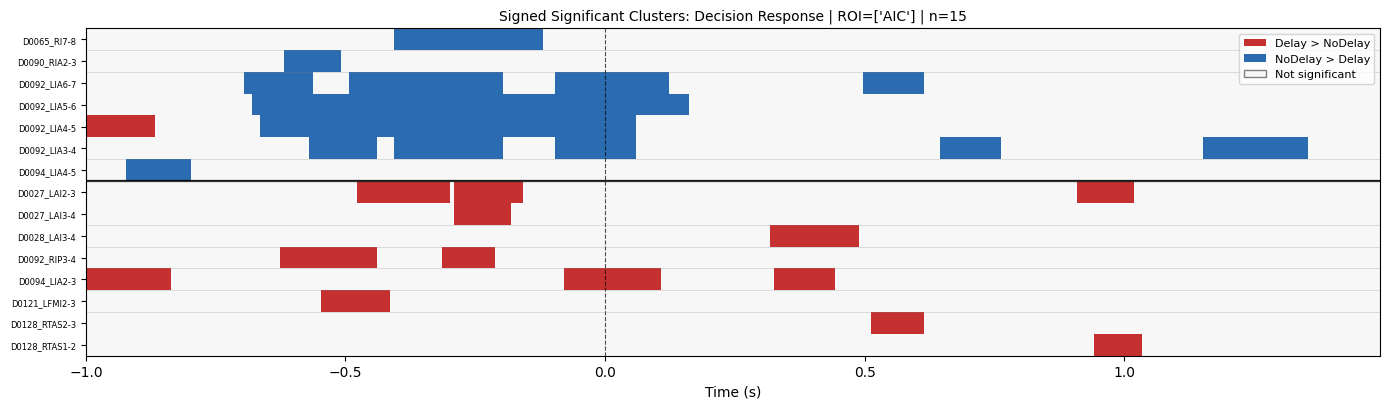

In [15]:
# ==========================================
# Signed heatmap: significant clusters (channel × time)
# red = Delay>NoDelay, blue = NoDelay>Delay
# direction-first sorting (blue channels grouped together)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# --- Settings ---
desc = 'Decision'           # 'Decision' or 'Repeat'
phase_list = ['response']
roi_filter = ['AIC']        # [] = all
time_range = (-1, 1.5)

blue_first = True           # True: blue block on top; False: red block on top
show_subject_separators = True

# --- Filter data ---
plot_df = cross_task[
    (cross_task.description == desc) &
    (cross_task.phase.isin(phase_list)) &
    (cross_task.time >= time_range[0]) &
    (cross_task.time <= time_range[1])
].copy()

if len(roi_filter) > 0:
    plot_df = plot_df[plot_df.roi.isin(roi_filter)].copy()

# keep channels with at least one significant point
sig_channels = plot_df[
    (plot_df['mask'] == True) & (plot_df['p'] < 0.05)
]['channel'].unique()
plot_df = plot_df[plot_df['channel'].isin(sig_channels)].copy()

print(f"Channels with significant clusters: {len(sig_channels)}")

if plot_df.empty:
    raise ValueError("No data left after filtering.")

# --- Build signed significance ---
plot_df['sig_bin'] = ((plot_df['mask'] == True) & (plot_df['p'] < 0.05)).astype(int)
plot_df['direction_sign'] = np.sign(plot_df['mean_diff']).astype(int)  # +1/-1/0
plot_df['signed_sig'] = plot_df['sig_bin'] * plot_df['direction_sign']  # non-sig -> 0

# robust aggregation if duplicate (channel,time) exists
def agg_signed(v):
    v = np.array(v, dtype=int)
    n_pos = np.sum(v == 1)
    n_neg = np.sum(v == -1)
    if n_pos > n_neg:
        return 1
    elif n_neg > n_pos:
        return -1
    else:
        return 0

heatmap_df = plot_df.pivot_table(
    index='channel',
    columns='time',
    values='signed_sig',
    aggfunc=agg_signed
).fillna(0).astype(int)

if heatmap_df.empty:
    raise ValueError("No channels/time points left for heatmap.")

# --- Direction-first sort ---
meta = pd.DataFrame({'channel': heatmap_df.index})
meta['subject'] = meta['channel'].str.extract(r'^(D\d+)', expand=False).fillna('Unknown')
meta['n_red'] = (heatmap_df == 1).sum(axis=1).values
meta['n_blue'] = (heatmap_df == -1).sum(axis=1).values
meta['n_sig_bins'] = (heatmap_df != 0).sum(axis=1).values

# dominant direction by counts
meta['dominant'] = np.where(meta['n_blue'] > meta['n_red'], 'blue', 'red')

def first_time_of_value(row, val):
    idx = np.where(row.values == val)[0]
    return row.index[idx[0]] if len(idx) > 0 else np.inf

meta = meta.set_index('channel')
meta['first_blue_time'] = heatmap_df.apply(lambda r: first_time_of_value(r, -1), axis=1)
meta['first_red_time'] = heatmap_df.apply(lambda r: first_time_of_value(r, 1), axis=1)
meta['first_dom_time'] = np.where(
    meta['dominant'] == 'blue',
    meta['first_blue_time'],
    meta['first_red_time']
)
meta = meta.reset_index()

if blue_first:
    dom_map = {'blue': 0, 'red': 1}
else:
    dom_map = {'red': 0, 'blue': 1}
meta['dom_key'] = meta['dominant'].map(dom_map)

# IMPORTANT: direction first, then subject
meta = meta.sort_values(
    ['dom_key', 'subject', 'first_dom_time', 'n_sig_bins', 'channel'],
    ascending=[True, True, True, False, True]
)
heatmap_df = heatmap_df.loc[meta['channel']]

# --- Plot ---
n_ch = len(heatmap_df)
fig_h = max(4, n_ch * 0.28)
fig, ax = plt.subplots(figsize=(14, fig_h))

cmap = ListedColormap(['#2b6cb0', '#f7f7f7', '#c53030'])  # blue, white, red
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

ax.imshow(
    heatmap_df.values,
    aspect='auto',
    cmap=cmap,
    norm=norm,
    interpolation='nearest',
    extent=[heatmap_df.columns.min(), heatmap_df.columns.max(), n_ch - 0.5, -0.5]
)

ax.set_xlabel('Time (s)', fontsize=10)
ax.set_title(
    f'Signed Significant Clusters: {desc} Response | ROI={roi_filter if roi_filter else "All"} | n={n_ch}',
    fontsize=10
)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

# y tick density control
if n_ch <= 35:
    yticks = np.arange(n_ch)
elif n_ch <= 80:
    yticks = np.arange(0, n_ch, 2)
else:
    yticks = np.arange(0, n_ch, 4)

ax.set_yticks(yticks)
ax.set_yticklabels(heatmap_df.index[yticks], fontsize=6)

# thick separator between blue block and red block
ordered_dom = meta.set_index('channel').loc[heatmap_df.index, 'dominant'].values
dom_change = np.where(ordered_dom[1:] != ordered_dom[:-1])[0] + 1
for i in dom_change:
    ax.axhline(i - 0.5, color='black', linewidth=1.6, alpha=0.9)

# optional subject separators (thin)
if show_subject_separators:
    ordered_subjects = meta.set_index('channel').loc[heatmap_df.index, 'subject'].values
    sub_change = np.where(ordered_subjects[1:] != ordered_subjects[:-1])[0] + 1
    for i in sub_change:
        ax.axhline(i - 0.5, color='gray', linewidth=0.5, alpha=0.35)

legend_handles = [
    Patch(facecolor='#c53030', edgecolor='none', label='Delay > NoDelay'),
    Patch(facecolor='#2b6cb0', edgecolor='none', label='NoDelay > Delay'),
    Patch(facecolor='#f7f7f7', edgecolor='gray', label='Not significant'),
]
ax.legend(handles=legend_handles, loc='upper right', frameon=True, fontsize=8)

plt.tight_layout()
# fig.savefig(f'../img/misc/cross_task_signed_heatmap_{desc}_direction_first.svg',
#             dpi=300, bbox_inches='tight')
plt.show()

In [20]:
meta.dom_key==1

3     False
4     False
8     False
7     False
6     False
5     False
11    False
0      True
1      True
2      True
9      True
10     True
12     True
14     True
13     True
Name: dom_key, dtype: bool

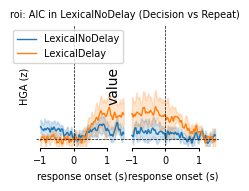

In [23]:
rois = ['AIC']
task_name = 'LexicalNoDelay'

# HGA traces (same as your existing plot)
pick = meta[meta.dom_key==1].channel.unique()
subset = HGAs[
    (HGAs.channel.isin(pick))
    & (HGAs.description=='Decision')
]

phases = ['stimulus', 'response']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*len(phases)*cm, 4*cm),
                         gridspec_kw={'width_ratios': [2.5]*len(phases)})
plt.subplots_adjust(wspace=0)

for ax, phase in zip(axes, phases):
    legend = (ax == axes[0])
    
    # 1. Draw HGA traces split by Decision / Repeat
    sns.lineplot(
        data=subset[subset.phase == phase],
        x='time', y='value',
        hue='task',
        ax=ax, legend=legend, lw=1
    )
    
for ax in axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.1, 1.5)

    ax.set_xlabel(f'{phase} onset (s)', fontsize=7)

axes[0].set_ylabel('HGA (z)', fontsize=7)

plt.suptitle(f'roi: {rois[0]} in {task_name} (Decision vs Repeat)', fontsize=7)
plt.show()

Subject counts:
subject
D0027    2
D0128    2
D0028    1
D0092    1
D0094    1
D0121    1
Name: count, dtype: int64


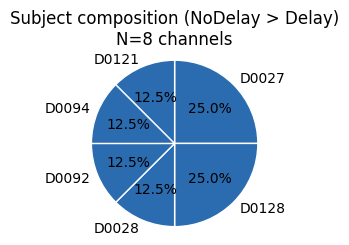

In [29]:
# ===== 只选一个方向 =====
# 你的代码里 dom_key: red=0, blue=1（如果你映射相反，请改这里）
direction_key = 1   # 1 = blue(NoDelay>Delay), 0 = red(Delay>NoDelay)

# 1) 从 meta 里拿该方向的数据（严格用 meta.subject）
sub_meta = meta[meta['dom_key'] == direction_key].copy()

# 2) 统计每个 subject 出现次数（每条记录就是一个 channel）
subject_counts = sub_meta['subject'].value_counts().sort_values(ascending=False)

print("Subject counts:")
print(subject_counts)

# 4) 最简单 pie chart
color = '#2b6cb0' if direction_key == 1 else '#c53030'
direction_label = 'NoDelay > Delay' if direction_key == 1 else 'Delay > NoDelay'

fig, ax = plt.subplots(figsize=(6*cm, 6*cm))
ax.pie(
    subject_counts.values,
    labels=subject_counts.index,
    autopct=lambda p: f'{p:.1f}%' if p > 0 else '',
    startangle=90,
    counterclock=False,
    colors=[color] * len(subject_counts),
    wedgeprops=dict(edgecolor='white', linewidth=1)
)
ax.set_title(f'Subject composition ({direction_label})\nN={subject_counts.sum()} channels')
ax.axis('equal')
plt.show()